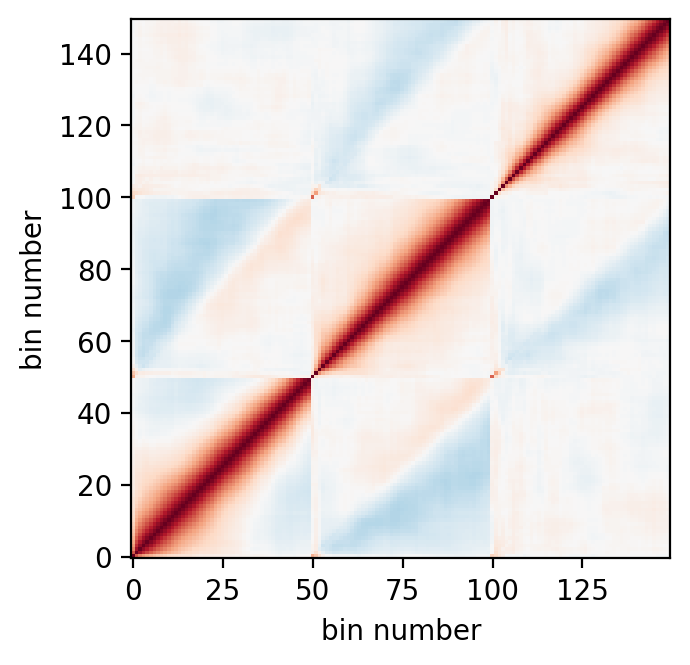

In [8]:
import acm.observables.emc as emc
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

def covariance_to_correlation(cov):
    """Convert a covariance matrix to a correlation matrix."""
    d = np.sqrt(np.diag(cov))
    corr = cov / np.outer(d, d)
    corr[cov == 0] = 0
    return corr

# define observable
observable = emc.GalaxyCorrelationFunctionMultipoles()

# calculate the (cosmic variance) covariance matrix
# (volume factor divides the small-box covariance)
cov_stat = observable.get_covariance_matrix(volume_factor=64)

corr_stat = covariance_to_correlation(cov_stat)

# plot the covariance matrix
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.imshow(corr_stat, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('bin number')
ax.set_ylabel('bin number')
plt.show()

In [2]:
# we can also access the individual realizations used to estimate the covariance
cov_y = observable.covariance_y
cov_y.shape

(1786, 150)

In [12]:
# we can get the joint covariance of multiple observables
import acm.observables.emc as emc
from acm.observables import CombinedObservable
joint_observable = CombinedObservable(
    [
        emc.GalaxyCorrelationFunctionMultipoles(),
        emc.DensitySplitCorrelationFunctionMultipoles(),
    ]
)

joint_observable.covariance_y.shape

(1786, 550)

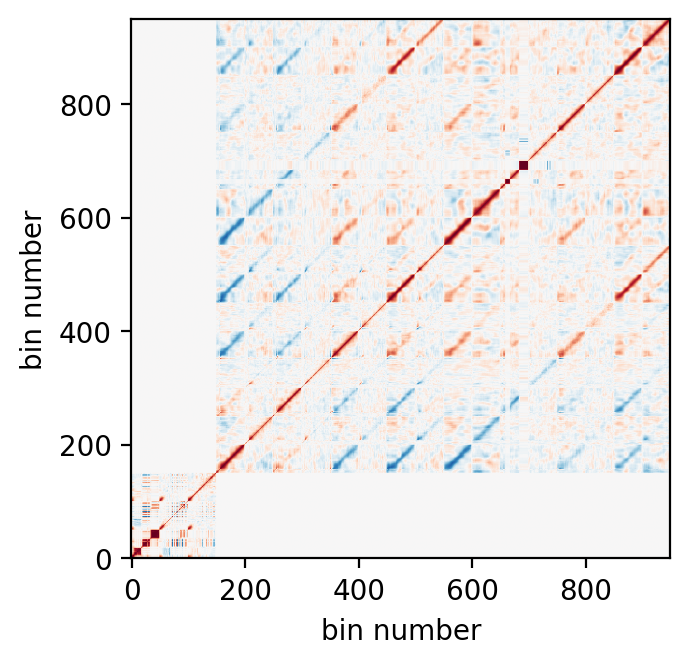

In [13]:
# calculate the matrix associated to the emulator error
# the joint covariance of many statistics will be block-diagonal
# unless we have the same test simulations for all statistics
cov_emul = joint_observable.get_emulator_covariance_matrix(block_diag=True)
corr_emul = covariance_to_correlation(cov_emul)

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.imshow(corr_emul, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('bin number')
ax.set_ylabel('bin number')
plt.show()